In [1]:
# General
import os
import sys
import pandas as pd
import numpy as np
import warnings
import importlib

# Plots 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Scverse libraries
import scanpy as sc
import anndata as ad

# Custom modules
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

import utils_scanpy
importlib.reload(utils_scanpy)

<module 'utils_scanpy' from '/home/bugani/updepla/users/bugani/projects/from_seurat_to_scanpy/bin/utils_scanpy.py'>

# Notebook Figure 6  

**Author(s):**  
**Date:**  
**Description:** This notebook reproduces the analyses and plots used to generate Figure 6 and Figure S6 of the manuscript.

### Input data

Running this notebook requires the following input files:  
1. .h5ad dataset with transcriptomic data:  
    - File name: '2024_CD8_stripie.tidy.scanpy.h5ad'  
    - Origin:
    - Location:    

### Output data

Running this notebook will generate the following output files:
- Plots only

In [2]:
## Se to True to save plots and tables generated throughout the notebook

# Save main plots 
save_plots = False
save_tables = False

# Save supplementary plots & other plots
save_sup_plots = False
save_other_plots = False

In [3]:
# Params
random_seed=432

analysis_id = "2024_CD8_stripie"
sample_ids = ['NG027', 'JP250', 'JP268', 'NG045']

species = 'human' 

In [28]:
# Paths
path_input_adata = f'/home/bugani/updepla/users/bugani/projects/from_seurat_to_scanpy/results/{analysis_id}/objects/2024_CD8_stripie.tidy.scanpy.h5ad'

# Insert output path for tables
path_output = '/home/bugani/updepla/users/bugani/projects/from_seurat_to_scanpy/results/mock_F6/'

# Insert output path for plots
path_output_figures = '/home/bugani/updepla/users/bugani/projects/from_seurat_to_scanpy/results/mock_F6/plots/'

# Create ouput folders if non-existing
if not os.path.exists(path_output):
    os.makedirs(path_output)
if not os.path.exists(path_output_figures):
    os.makedirs(path_output_figures)

## 1. Transcriptomic Analyses

In this section of the notebook we perfom single-cell transcriptomic analyses of CD8 T cells to identify cell types and expression patterns. We label cells based on their morphological classes derived from IRIS images: (1) TØ, ‘Stripy’ cells, and (2) TO, ‘Conventional’ T cells. 

We start by loading an anndata object containing the pre-processed dataset.

In [5]:
# Read adata 
adata_tidy = sc.read(path_input_adata)
adata_tidy

Only considering the two last: ['.scanpy', '.h5ad'].
Only considering the two last: ['.scanpy', '.h5ad'].


AnnData object with n_obs × n_vars = 3702 × 11860
    obs: 'sample', 'Sample_ID', 'expID', 'Sample_Well', 'Lane', 'I7_Index_ID', 'index', 'Full_Cell_ID', 'I5_Index_ID', 'index2', 'Sample_Project', 'Description', 'Species', 'CC_used', 'Condition_per_CC', 'ERCC', 'Exp_Condition_1', 'Exp_Condition_2', 'Exp_Condition_3', 'Tn5_FragmentSize', 'Tn5_Yield', 'Sample_ID_2', 'CC', 'Dropout_Type', 'n_UMI', 'n_genes', 'n_all_reads', 'n_mapped_reads', 'ratio_UMI_to_mapped_reads', 'CellType_Condition', 'Stripie_manual', 'n_cell_ROI', 'stripy_manual_solid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hsp', 'log1p_total_counts_hsp', 'pct_counts_hsp', 'S_score', 'G2M_score', 'phase', 'leiden', 'Cluster

In [6]:
## Define color palette for cell types
cluster_colors_map = {
    'Naive': '#4A90E2', 
    'CMlike': '#91f089', 
    'EM': '#48bf53',
    'TEMRA': '#11823b' 
}

adata_tidy.obs['Cluster_names'] = pd.Categorical(adata_tidy.obs['Cluster_names'])
adata_tidy.uns['Cluster_names_colors'] = [cluster_colors_map[label] for label in adata_tidy.obs['Cluster_names'].cat.categories]

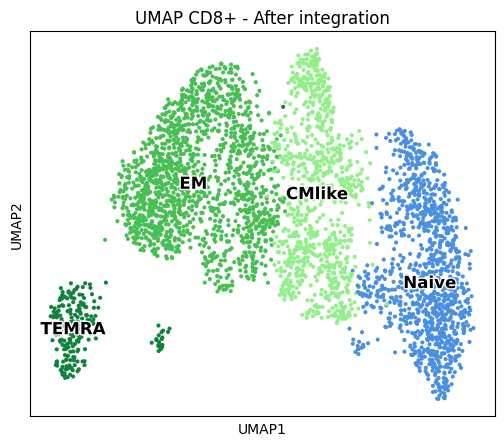

In [7]:
### --- Plot UMAP, cells colored by cell type --- ###
fig, axes = plt.subplots(1,1, figsize=(6,5))

sc.pl.umap(
    adata_tidy,
    color=["Cluster_names"],
    size=35,
    title=["UMAP CD8+ - After integration"],
    legend_loc='on data', legend_fontweight='semibold', legend_fontoutline=2, legend_fontsize='large',
    ax=axes)

if save_plots:
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_tidy.legend_on_data.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_tidy.legend_on_data.eps'), dpi=300, bbox_inches='tight')

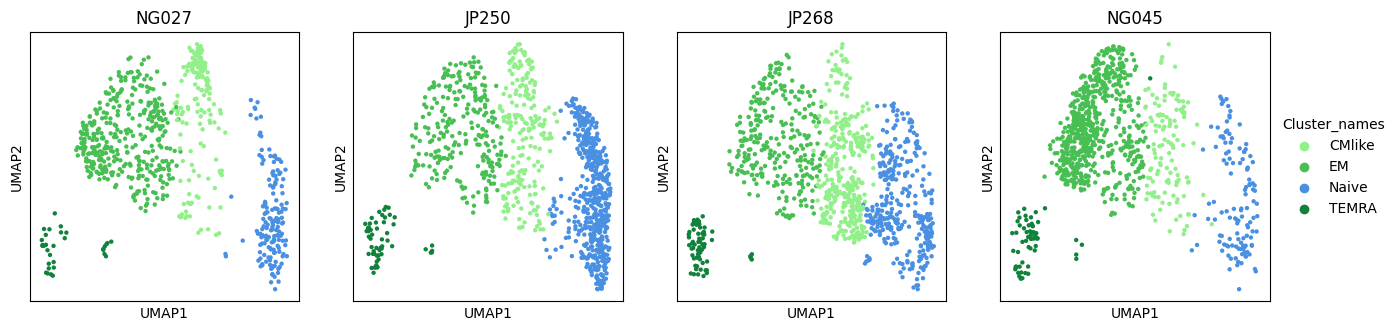

In [8]:
### --- Plot UMAPs, cells split by donor --- ###
fig = utils_scanpy.plot_split_umap(adata_tidy, 
                             split_by='sample', 
                             color_by='Cluster_names', 
                             size=40, 
                             figsize=(4, 3.5))

if save_sup_plots:
    fig.savefig(os.path.join(path_output_figures,'UMAPs_CD8_tidy.split_by_donor.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAPs_CD8_tidy.split_by_donor.eps'), dpi=300, bbox_inches='tight')

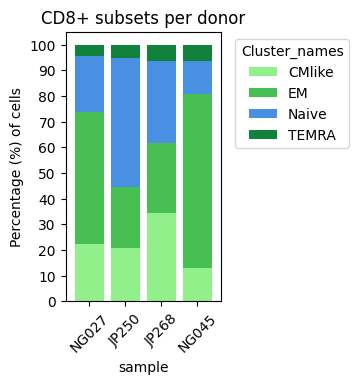

In [9]:
### --- Plot Bargraph with proportion of CD8+ subsets per donor --- ###
warnings.filterwarnings("ignore")

colors = {
    'Naive': '#4A90E2', 
    'CMlike': '#91f089', 
    'EM': '#48bf53',
    'TEMRA': '#11823b'
}

fig, axes = plt.subplots(1,1, figsize=(2, 3.5))

utils_scanpy.plot_subsets_distribution(adata=adata_tidy, 
                                       category1='sample', 
                                       category2='Cluster_names', 
                                       title = 'CD8+ subsets per donor', 
                                       colors=colors, 
                                       ax=axes)

if save_sup_plots:
    fig.savefig(os.path.join(path_output_figures,'Bargraph_prop_CD8_subsets.per_donor.smaller.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'Bargraph_prop_CD8_subsets.per_donor.smaller.eps'), dpi=300, bbox_inches='tight')

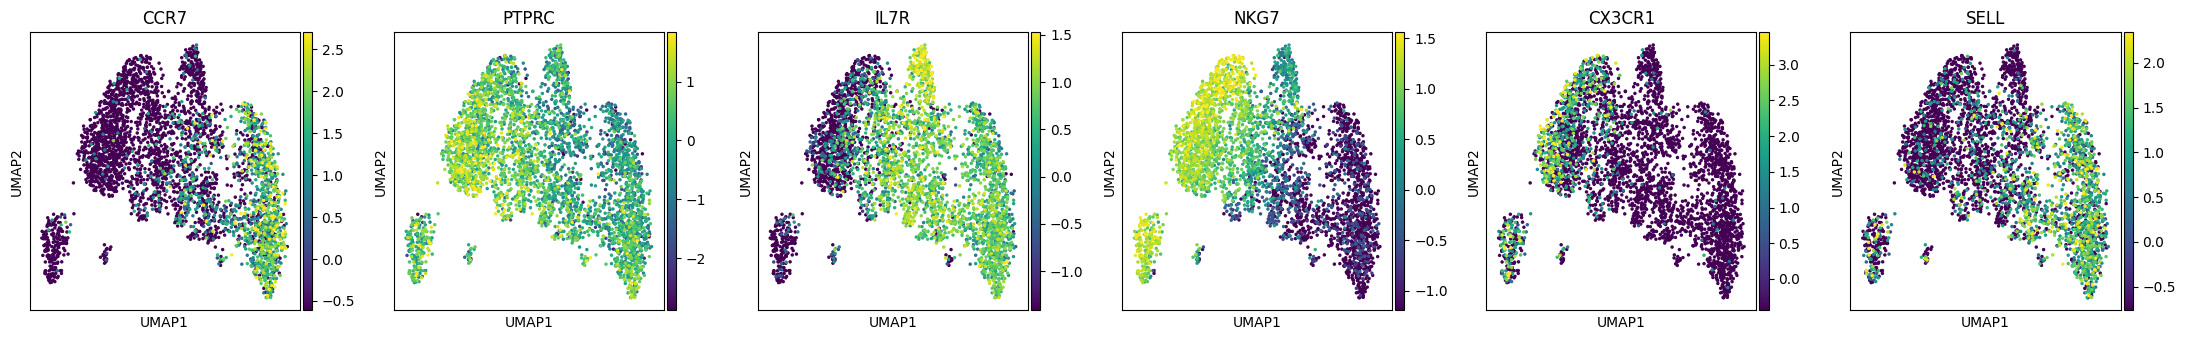

In [10]:
### --- Plot UMAPs with marker genes expression --- ###

fig, axes = plt.subplots(1, 6, figsize=(22, 3.5))
axes = axes.flatten()

for i, marker in enumerate(["CCR7", "PTPRC", "IL7R", "NKG7", "CX3CR1", "SELL"]):
    sc.pl.umap(
        adata_tidy,
        color=marker,
        size=25,  
        show=False, ncols = 1, 
        vmin = 'p1', vmax='p99', 
        ax = axes[i]
    )       
    
plt.tight_layout()

if save_sup_plots:
    fig.savefig(os.path.join(path_output_figures,'UMAPs_CD8_tidy.marker_genes.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAPs_CD8_tidy.marker_genes.eps'), dpi=300, bbox_inches='tight')

In [11]:
# Rename Stripy and Conventional cells 
adata_tidy.obs['stripy_manual_solid'] = adata_tidy.obs['stripy_manual_solid'].cat.rename_categories({
    'stripy_center': 'TØ Stripy',
    'normi_circle': 'TO Conventional'
})

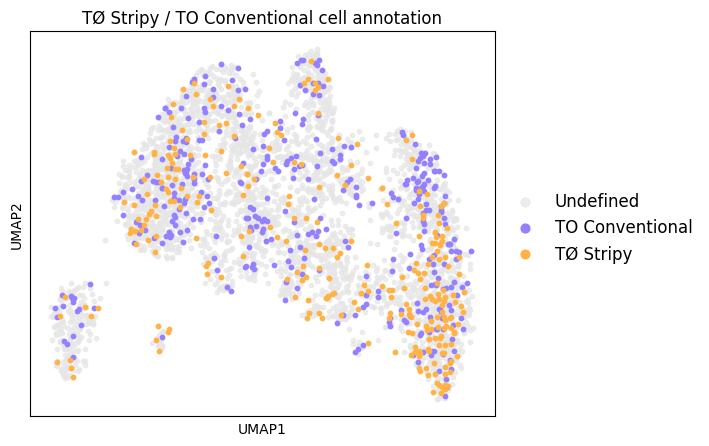

In [12]:
# E: remove? Not in FS6 anymore?
### --- Plot UMAP with cells labeled based on Stripy/Conventional annotation --- ###
warnings.filterwarnings("ignore")

colors_stripy_normi = {
    'TØ Stripy' : '#FFB347', 
    'TO Conventional' : '#9381FF', 
    'Undefined' :'#e6e6e6'
}

umap_df = adata_tidy.obsm['X_umap']
categories = adata_tidy.obs["stripy_manual_solid"]

# Separate data for specific categories
stripy_data = umap_df[categories == "TØ Stripy"]
normi_data = umap_df[categories == "TO Conventional"]
other_data = umap_df[~categories.isin(["TØ Stripy", "TO Conventional"])]

size=10

# Plot in layers: 
fig = plt.figure(figsize=(6,5))

plt.scatter(
    other_data[:, 0], other_data[:, 1], 
    s=size, c="#e6e6e6", label="Undefined", alpha=0.7
)
plt.scatter(
    normi_data[:, 0], normi_data[:, 1], 
    s=size, c="#9381FF", label="TO Conventional"
)
plt.scatter(
    stripy_data[:, 0], stripy_data[:, 1], 
    s=size, c="#FFB347", label="TØ Stripy"
)

# Add titles and legends
plt.title("TØ Stripy / TO Conventional cell annotation")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.xticks([]) 
plt.yticks([])  
legend = plt.legend(loc='upper right', frameon=False,
          bbox_to_anchor=(1.44, 0.6), borderaxespad=0., 
          fontsize='large', scatterpoints=1)

for handle in legend.legendHandles:
    handle._sizes = [40] 

if save_other_plots:
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_tidy.colored_by_stripy_manual_solid.manual.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_tidy.colored_by_stripy_manual_solid.manual.eps'), dpi=300, bbox_inches='tight')

## 2. CD8+ Naive cells further analyses 

In this section of the notebook we perform further analyses on the CD8+ Naive subset.   
We re-embed the cells of the CD8+ Naive subset, perform clustering with increased clustering resolution to identify additional clusters, and we perform DGE analysis between Stripy and Conventional cells.

#### Re-embedding of CD8+ Naive cells

In [13]:
# Create a copy
adata_re = adata_tidy.copy()

In [14]:
### --- Define params for re-embedding --- ###

n_pcs_re = 50
n_pcs_use_re=30 
n_neighbors_re=14
min_dist_re=0.5
spread_re=0.5
resolution_re=0.2 

In [15]:
### --- Re-embed CD8+ Naive cells --- ###

clust = 'Naive'
adata_naive_re = adata_re[adata_re.obs['Cluster_names'] == clust, :].copy()

# Re-perform analyses
sc.pp.highly_variable_genes(adata_naive_re, n_top_genes=2000)
sc.pp.scale(adata_naive_re, max_value=10)

mask = ~np.isnan(adata_naive_re.X).any(axis=0)
adata_naive_re = adata_naive_re[:, mask]

sc.tl.pca(adata_naive_re, n_comps=n_pcs_re, random_state=random_seed)
n_pcs_use_re = min(n_pcs_use_re, adata_naive_re.obsm['X_pca_harmony'].shape[1])
print(f"N PCs: {n_pcs_use_re}")

sc.pp.neighbors(adata_naive_re, 
                random_state=random_seed, 
                n_neighbors=n_neighbors_re, 
                n_pcs=n_pcs_use_re,
                use_rep='X_pca_harmony')

sc.tl.umap(adata_naive_re, 
           random_state=random_seed,  
           min_dist=min_dist_re, 
           spread=spread_re) 

# Re-cluster re-embedded CD8+ Naive cells 
sc.tl.leiden(adata_naive_re, 
             resolution=resolution_re, 
             random_state=random_seed)

N PCs: 27


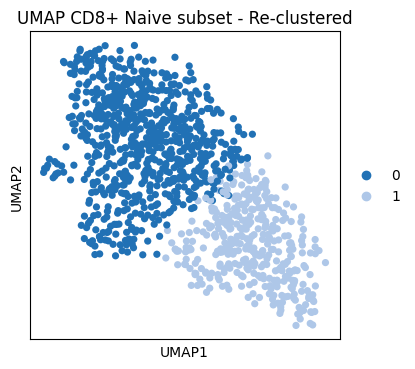

In [16]:
## Plot UMAP of re-embedded cells

# Define colors
custom_colors = {
    '0': '#2171b5',  
    '1': '#aec7e8'  
}

adata_naive_re.obs['leiden'] = adata_naive_re.obs['leiden'].astype('category')
adata_naive_re.uns['leiden_colors'] = [
    custom_colors[cat] if cat in custom_colors else '#000000'
    for cat in adata_naive_re.obs['leiden'].cat.categories
]


fig, ax = plt.subplots(1,1, figsize=(4, 4))

sc.pl.umap(
    adata_naive_re,
    color=['leiden'],
    size=None,
    title=["UMAP CD8+ Naive subset - Re-clustered"], 
    palette=custom_colors,
    ax=ax
)

if save_plots:
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_Naive.higher_resolution_clust.re_embed_2.squared.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_Naive.higher_resolution_clust.re_embed_2.squared.eps'), dpi=300, bbox_inches='tight')

N. of cells in mask: 5
Cells not in mask: ['NG045_P2_WC9_CC8']


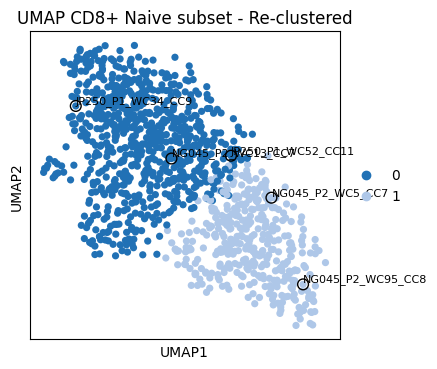

In [17]:
### Plot UMAP with highlighted cells 

# Plot UMAP
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

sc.pl.umap(
    adata_naive_re,
    color=['leiden'],
    size=None,
    show=False,
    title=["UMAP CD8+ Naive subset - Re-clustered"], 
    palette=custom_colors,
    ax=ax
)

# Highlighted selected cells
highlight_cells = [
    'JP250_P1_WC34_CC9',
    'JP250_P1_WC52_CC11',
    'NG045_P2_WC5_CC7',
    'NG045_P2_WC13_CC7',
    'NG045_P2_WC9_CC8',
    'NG045_P2_WC95_CC8'
]

umap_coords = adata_naive_re.obsm['X_umap']
obs_names = adata_naive_re.obs_names

highlight_mask = obs_names.isin(highlight_cells)
print(f"N. of cells in mask: {highlight_mask.sum()}")
print(f"Cells not in mask: {[c for c in highlight_cells if c not in obs_names]}")

# Scatter plot for highlighted cells
ax.scatter(
    umap_coords[highlight_mask, 0],
    umap_coords[highlight_mask, 1],
    s=60,
    facecolors='none',
    edgecolors='black',
    linewidths=1,
    label='Highlighted cells',
    zorder=3
)

# Add text labels for highlighted cells
for i, cell in enumerate(obs_names[highlight_mask]):
    x, y = umap_coords[highlight_mask][i]
    ax.text(
        x, y, cell,                 # coordinates and text
        fontsize=8,                 # adjust as needed
        ha='left', va='bottom',     # position of text relative to point
        color='black',
        zorder=4
    )

plt.show()

if save_other_plots:
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_Naive.higher_resolution_clust.re_embed_2.cells_highlighted.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_Naive.higher_resolution_clust.re_embed_2.cells_highlighted.eps'), dpi=300, bbox_inches='tight')

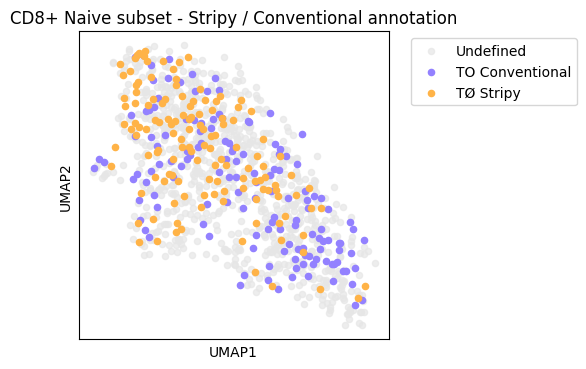

In [18]:
## Plot UMAP, cells colored based on Stripy / Conventional annotation

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

utils_scanpy.plot_stripy_umap(
    adata_naive_re,
    group_key="stripy_manual_solid",
    colors=colors_stripy_normi,
    title="CD8+ Naive subset - Stripy / Conventional annotation", 
    ax=ax
)

ax.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')

if save_plots: 
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_Naive.higher_resolution_clust.re_embed_2.colored_by_stripy_manual_solid.squared.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'UMAP_CD8_Naive.higher_resolution_clust.re_embed_2.colored_by_stripy_manual_solid.squared.eps'), dpi=300, bbox_inches='tight')

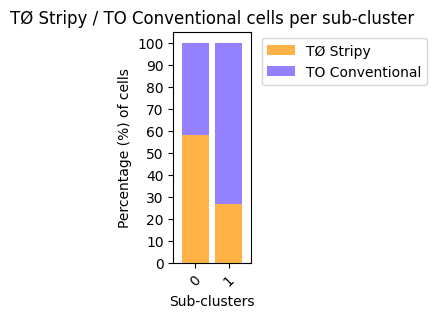

In [19]:
## Plot bargraph of proportions of Stripy and Conventional cells across clusters  

df_clusters = adata_naive_re.obs[adata_naive_re.obs['leiden'].isin(['0','1'])]
df_clusters_filt = df_clusters[df_clusters['stripy_manual_solid'] != 'Undefined']

fig, ax = plt.subplots(1, 1, figsize=(1, 3))

utils_scanpy.plot_subsets_distribution(
    df_clusters_filt, 
    category1='leiden', x_axis_order=['0', '1'],
    category2='stripy_manual_solid', y_axis_order=['TØ Stripy', 'TO Conventional'],
    title = 'TØ Stripy / TO Conventional cells per sub-cluster', 
    colors=colors_stripy_normi, 
    ax=ax
)

ax.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("Sub-clusters")

if save_plots:
    fig.savefig(os.path.join(path_output_figures,'Bargraph_prop_stripy.CD8_naive.higher_resolution_clust.re_embed_2.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'Bargraph_prop_stripy.CD8_naive.higher_resolution_clust.re_embed_2.eps'), dpi=300, bbox_inches='tight')

#### Differential Gene Expression analysis - Stripy vs. Conventional cells

In [20]:
### --- Prepare data for DGE between Stripy and Conventional cells --- ###

# Variable containing Stripy / Conventional annotation
group_var = 'stripy_manual_solid'

# CD8+ subset to perform DGE 
clust = 'Naive'

# Contrasting groups
group1 = 'TØ Stripy'
group2 = 'TO Conventional'

# Thresholds
pval_thresh = 0.05
pval_adj_thresh = 0.05
sort_by='pval_adj'

logFC_thresh = 0.5
min_pct_thresh = 0.25

# DGE method
method = 'wilcoxon' 

## Prepare objects for DGE analysis
print(f'#### Performing stripy vs. normi DGE analysis on cluster {clust}. ####')

DEGs_pos_stripy_normi = {}
DEGs_pos_stripy_normi_filt = {}

filt = adata_tidy.obs[ (adata_tidy.obs['Cluster_names'] == clust) & (adata_tidy.obs['stripy_manual_solid'] != 'Undefined') ]['stripy_manual_solid']
filt_counts = filt.value_counts()
print("Number of cells x group: ", dict(filt_counts.drop('Undefined')), "\n")

# Subset cells from a specific cluster 
adata_subset = adata_tidy[adata_tidy.obs['Cluster_names'] == clust, :].copy()

DEGs_pos_stripy_normi[clust] = {}
DEGs_pos_stripy_normi_filt[clust] = {}

#### Performing stripy vs. normi DGE analysis on cluster Naive. ####
Number of cells x group:  {'TO Conventional': 141, 'TØ Stripy': 133} 



In [21]:
### --- Perform DGE on Stripy vs. Conventional cells, all cells --- ###

print(f'Stripy vs. Normi')
sc.tl.rank_genes_groups(adata_subset, 
                        groupby=group_var, 
                        groups=[group1], reference=group2, 
                        method=method, 
                        pts=True, 
                        layer='log_norm')
DEGs_stripy_clust = sc.get.rank_genes_groups_df(adata_subset, group=None)
DEGs_stripy_clust = DEGs_stripy_clust.rename(columns={'logfoldchanges' : 'logFC'})

# Get positive DEGs in Stripy vs. Conventional 
DEGs_stripy_clust = DEGs_stripy_clust[ (DEGs_stripy_clust['logFC'] > 0) ]
DEGs_pos_stripy_normi[clust][group1] = DEGs_stripy_clust


### --- Perform DGE between Stripy and Conventional cells, filtered cells --- ###

# Filter genes of interest - respecting logFC and min_pct thresholds
genes_stripy_clust_filt = DEGs_stripy_clust.copy()
genes_stripy_clust_filt = genes_stripy_clust_filt[
    (genes_stripy_clust_filt['logFC'] >= logFC_thresh) &
    (genes_stripy_clust_filt['pct_nz_group'] >= min_pct_thresh)
    ]
genes_of_int = genes_stripy_clust_filt['names']

# Create genes mask  
genes_mask = adata_subset.var_names.isin(genes_of_int)

# Perform again DGE on genes of interest
print(f'Performing DGE also on filtered set of genes. {genes_mask.sum()} genes after filtering, previously: {adata_subset.var.shape[0]}')
sc.tl.rank_genes_groups(adata_subset, 
                        groupby=group_var, 
                        groups=[group1], reference=group2, 
                        method=method, 
                        pts=True, 
                        layer='log_norm', 
                        mask_var=genes_mask
                       )
DEGs_stripy_clust_filt = sc.get.rank_genes_groups_df(adata_subset, group=None)
DEGs_stripy_clust_filt = DEGs_stripy_clust_filt.rename(columns={'logfoldchanges' : 'logFC'})

# Get positive DEGs in Stripy vs. Conventional 
DEGs_stripy_clust_filt = DEGs_stripy_clust_filt[ (DEGs_stripy_clust_filt['logFC'] > 0) ]
DEGs_pos_stripy_normi_filt[clust][group1] = DEGs_stripy_clust_filt

Stripy vs. Normi
Performing DGE also on filtered set of genes. 732 genes after filtering, previously: 11860


In [22]:
## Define a custom colormap for plotting
low_colors = ['#2166ac', '#67a9cf', '#d1e5f0']  
high_colors = ['#b2182b', '#ef8a62', '#fddbc7']  
mid_color = 'white' 

colors = low_colors + [mid_color] + high_colors[::-1]  
cmap_custom = LinearSegmentedColormap.from_list('custom_blue_red', colors)

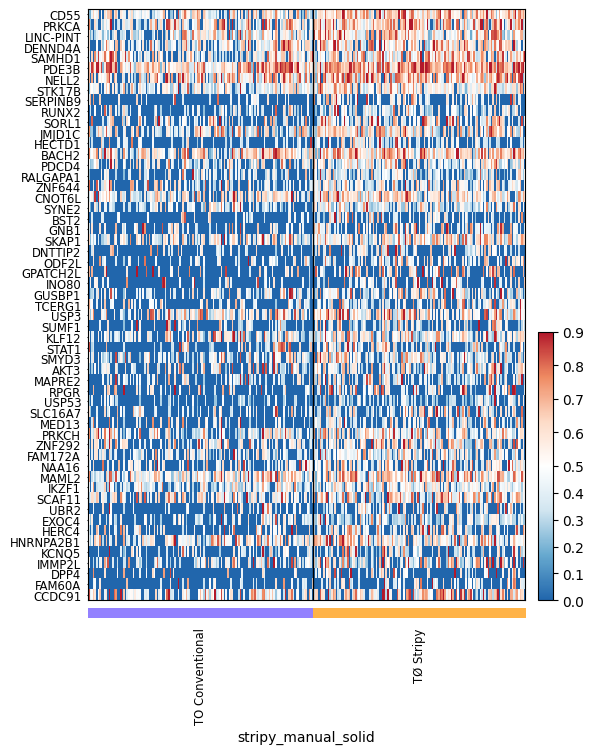

In [23]:
### --- Plot Heatmap of Top 55 DEGs in Stripy vs. Conventional (Naive subset) --- ###

clust = 'Naive'
n_genes = 55

# Subset cells of Naive subset
adata_subset = adata_tidy[ (adata_tidy.obs['Cluster_names'] == clust) & (adata_tidy.obs['stripy_manual_solid'] != 'Undefined') , :].copy()
adata_subset.uns['stripy_manual_solid_colors'] = ['#9381FF', '#FFB347']

DEGs_df = DEGs_pos_stripy_normi_filt
markers_up = list(DEGs_df[clust][group1].head(n_genes).names)

cmap = cmap_custom
sc.pl.heatmap(adata_subset, 
              markers_up, 
              groupby=group_var, 
              swap_axes=True, 
              show=False, 
              figsize=(6,8), 
              standard_scale='var', 
              cmap=cmap, 
              vmax=0.9, vcenter=0.5,  
              show_gene_labels=True)

fig = plt.gcf()
if save_plots:
    fig.savefig(os.path.join(path_output_figures,'Heatmap_top55_up.stripy_normi.Naive.cmap_custom2.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'Heatmap_top55_up.stripy_normi.Naive.cmap_custom2.eps'), dpi=300, bbox_inches='tight')

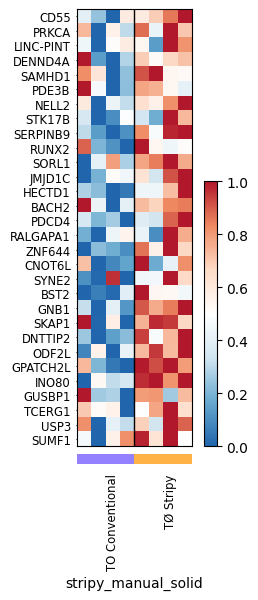

In [24]:
### --- Plot Heatmap of Top 30 DEGs in Stripy vs. Conventional (Naive subset) --- ###

# Expression aggregated per donor

clust = 'Naive'
n_genes = 30
cmap = cmap_custom 
group_var = 'sample'  

layer = 'counts' # for raw counts
stat = 'sum' # for pseudo-bulk)

# Subset cells of Naive subset and remove 'Undefined' ones
adata_subset = adata_tidy[ (adata_tidy.obs['Cluster_names'] == clust) & (adata_tidy.obs['stripy_manual_solid'] != 'Undefined') , :].copy()

# Select DEGs of interest
DEGs_df = DEGs_pos_stripy_normi_filt
markers_up = list(DEGs_df[clust][group1].head(n_genes).names)

# Extract expression values from adata + metadata
adata_subset_X = pd.DataFrame(adata_subset.layers[layer])
adata_subset_X = adata_subset_X.set_index(adata_subset.obs.index)
adata_subset_X.columns = adata_subset.var_names

# Add donor and stripy/conventional annotation information
adata_subset_X = adata_subset_X.merge(adata_subset.obs[['sample', 'stripy_manual_solid']], left_index=True, right_index=True)

# Compute x gene sum expression x donor 
if stat == 'sum':
    merged_expr = adata_subset_X.groupby(['stripy_manual_solid', 'sample']).sum()    

# Convert back to adata
adata_grouped = sc.AnnData(X=merged_expr.values)
adata_grouped.var_names = merged_expr.columns
adata_grouped.obs_names = merged_expr.index

adata_grouped.obs['sample'] = merged_expr.index.get_level_values('sample')
adata_grouped.obs['stripy_manual_solid'] = merged_expr.index.get_level_values('stripy_manual_solid')
adata_grouped.uns['stripy_manual_solid_colors'] = ['#9381FF', '#FFB347']

# Normalize each cell by total counts over all genes
sc.pp.normalize_total(adata_grouped, exclude_highly_expressed=False, target_sum=1e4)

# Log-transform the data 
sc.pp.log1p(adata_grouped) 

# Plot heatmap
sc.pl.heatmap(adata_grouped, 
              markers_up, 
              groupby='stripy_manual_solid',
              swap_axes=True, 
              figsize=(1.8,6), 
              standard_scale='var', 
              cmap=cmap_custom, 
              use_raw=False, 
              show=False)

fig = plt.gcf()
if save_plots:
    fig.savefig(os.path.join(path_output_figures,'Heatmap_squares_top30_up.stripy_normi.Naive.grouped_by_sample.sum_counts.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'Heatmap_squares_top30_up.stripy_normi.Naive.grouped_by_sample.sum_counts.eps'), dpi=300, bbox_inches='tight')

#### Gene set enrichement analysis 

GSE analysis was performed on DEGs up-regulated in Naive Stripy cells. 

- Script for the analysis: 'Combined_CD8_GeneOntology_bubbleplot.R'
- Location: repo_location/ 

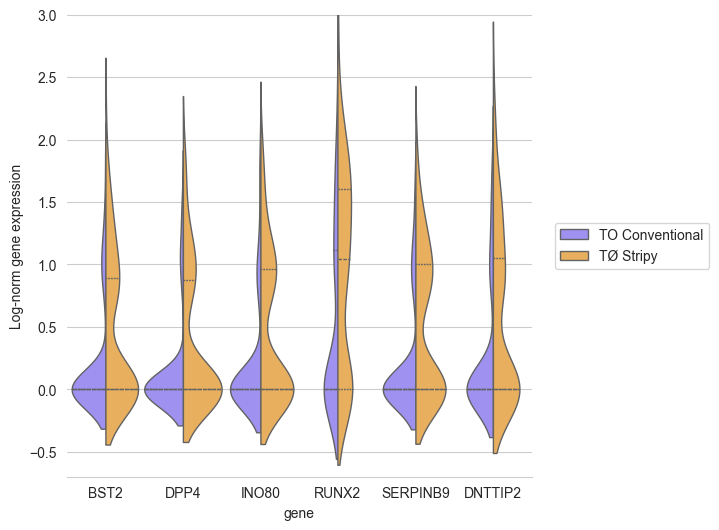

In [26]:
### --- Plot expression of selected validated genes in Naive Stripy vs. Conventional cells --- ### 

# Select genes of interest 
val_genes = ['BST2', 'DPP4', 'INO80', 'RUNX2', 'SERPINB9', 'DNTTIP2']
vars_to_plot = val_genes + ['stripy_manual_solid']

# Subset cells of Naive subset and remove 'Undefined' ones
adata_subset = adata_tidy[ (adata_tidy.obs['Cluster_names'] == clust) & (adata_tidy.obs['stripy_manual_solid'] != 'Undefined') , :].copy()

layer = 'log_norm'

# Prepare data
df = sc.get.obs_df(adata_subset, vars_to_plot, layer=layer)
df = df.set_index('stripy_manual_solid').stack().reset_index()
df.columns = ['stripy_manual_solid', 'gene', 'value']

## Plot
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sns.violinplot(data=df, 
               x='gene', 
               y='value', 
               hue="stripy_manual_solid", 
               palette=colors_stripy_normi,
               split=True, 
               inner="quart", 
               linewidth=1, 
               width=1,
               ax=axes)

axes.set_ylim(-0.7, 3)
axes.set_ylabel(f'{'Log-norm' if layer=='log_norm' else 'Scaled'} gene expression')
sns.despine(ax=axes, top=True, right=True, bottom=False, left=True)

handles, labels = axes.get_legend_handles_labels()
axes.legend(
    handles, labels,
    title="",
    bbox_to_anchor=(1.05, 0.5),
    loc='center left',
    borderaxespad=0.
)

if save_plots:
    fig.savefig(os.path.join(path_output_figures,'Violin_split.val_genes.naive_stripy_normi.log_norm.pdf'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(path_output_figures,'Violin_split.val_genes.naive_stripy_normi.log_norm.eps'), dpi=300, bbox_inches='tight')

In [27]:
# Get Adjusted P-values of genes of interest 
DEGs_pos_stripy_normi_filt['Naive']['TØ Stripy'][
    (DEGs_pos_stripy_normi_filt['Naive']['TØ Stripy']['names'].isin(val_genes))
]

,names,scores,logFC,pvals,pvals_adj,pct_nz_group
8,SERPINB9,4.188798,1.622144,0.000028,0.002281,0.481203
9,RUNX2,3.956935,1.124511,0.000076,0.005498,0.646617
19,BST2,3.590071,1.538226,0.000331,0.011720,0.428571
22,DNTTIP2,3.561851,1.397006,0.000368,0.011720,0.466165
25,INO80,3.452784,1.369412,0.000555,0.015621,0.428571
52,DPP4,3.118717,1.595659,0.001816,0.025087,0.353383


In [36]:
### End of Notebook ###